Updated model to modify for normalization N and baseline B.

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [5]:
from src.RealDataReplication import RealDataReplicationDeconvolution
from src.config import load_default_chrom_configs

config, _ = load_default_chrom_configs()
real_deconv1 = RealDataReplicationDeconvolution(config, replicate=1)

todo: Copy correction is not in place


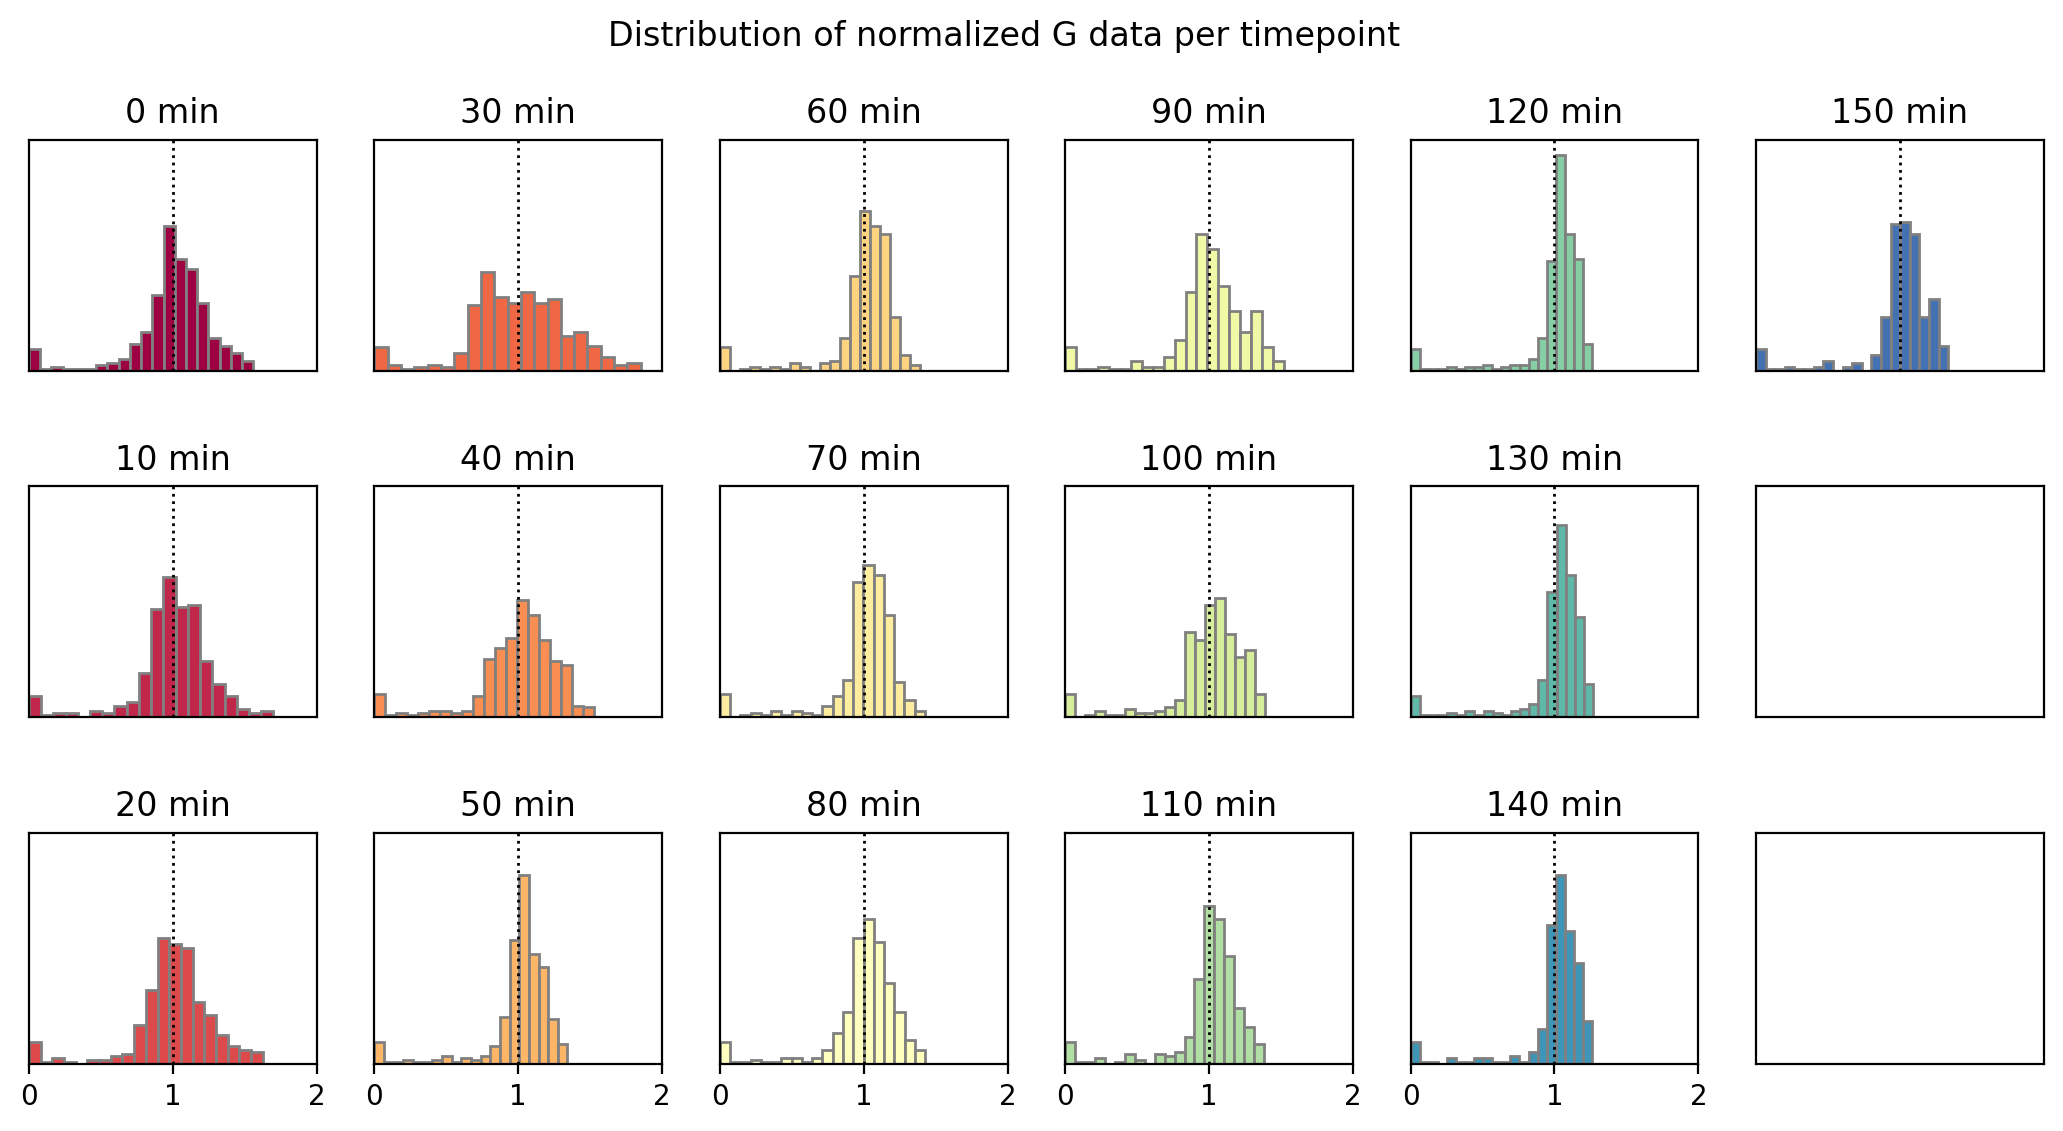

In [11]:
from src.RealDataReplication import plot_histogram_occupancies_G
plot_histogram_occupancies_G(real_deconv1.config, real_deconv1.G)

###### 

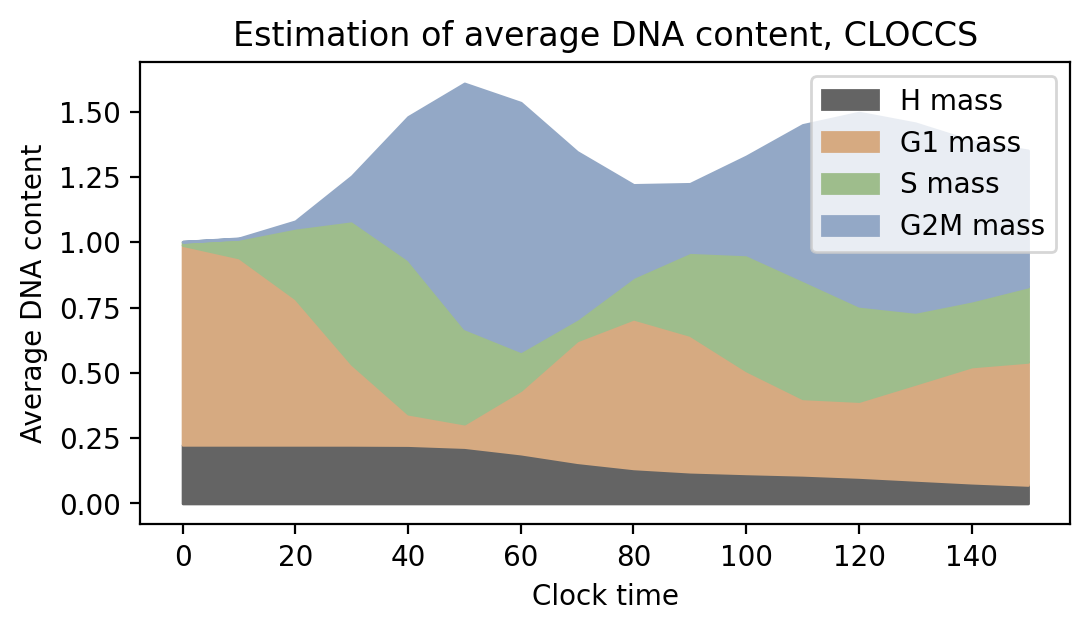

In [14]:
from src.RealDataReplication import compute_N
_ = compute_N(real_deconv1.config, plot=True)

In [20]:
real_deconv1.deconvolve()

0/368 - 00:00:00.000
50/368 - 00:00:04.536
100/368 - 00:00:08.811
150/368 - 00:00:13.410
200/368 - 00:00:17.877
250/368 - 00:00:22.356
300/368 - 00:00:27.476
350/368 - 00:00:31.975


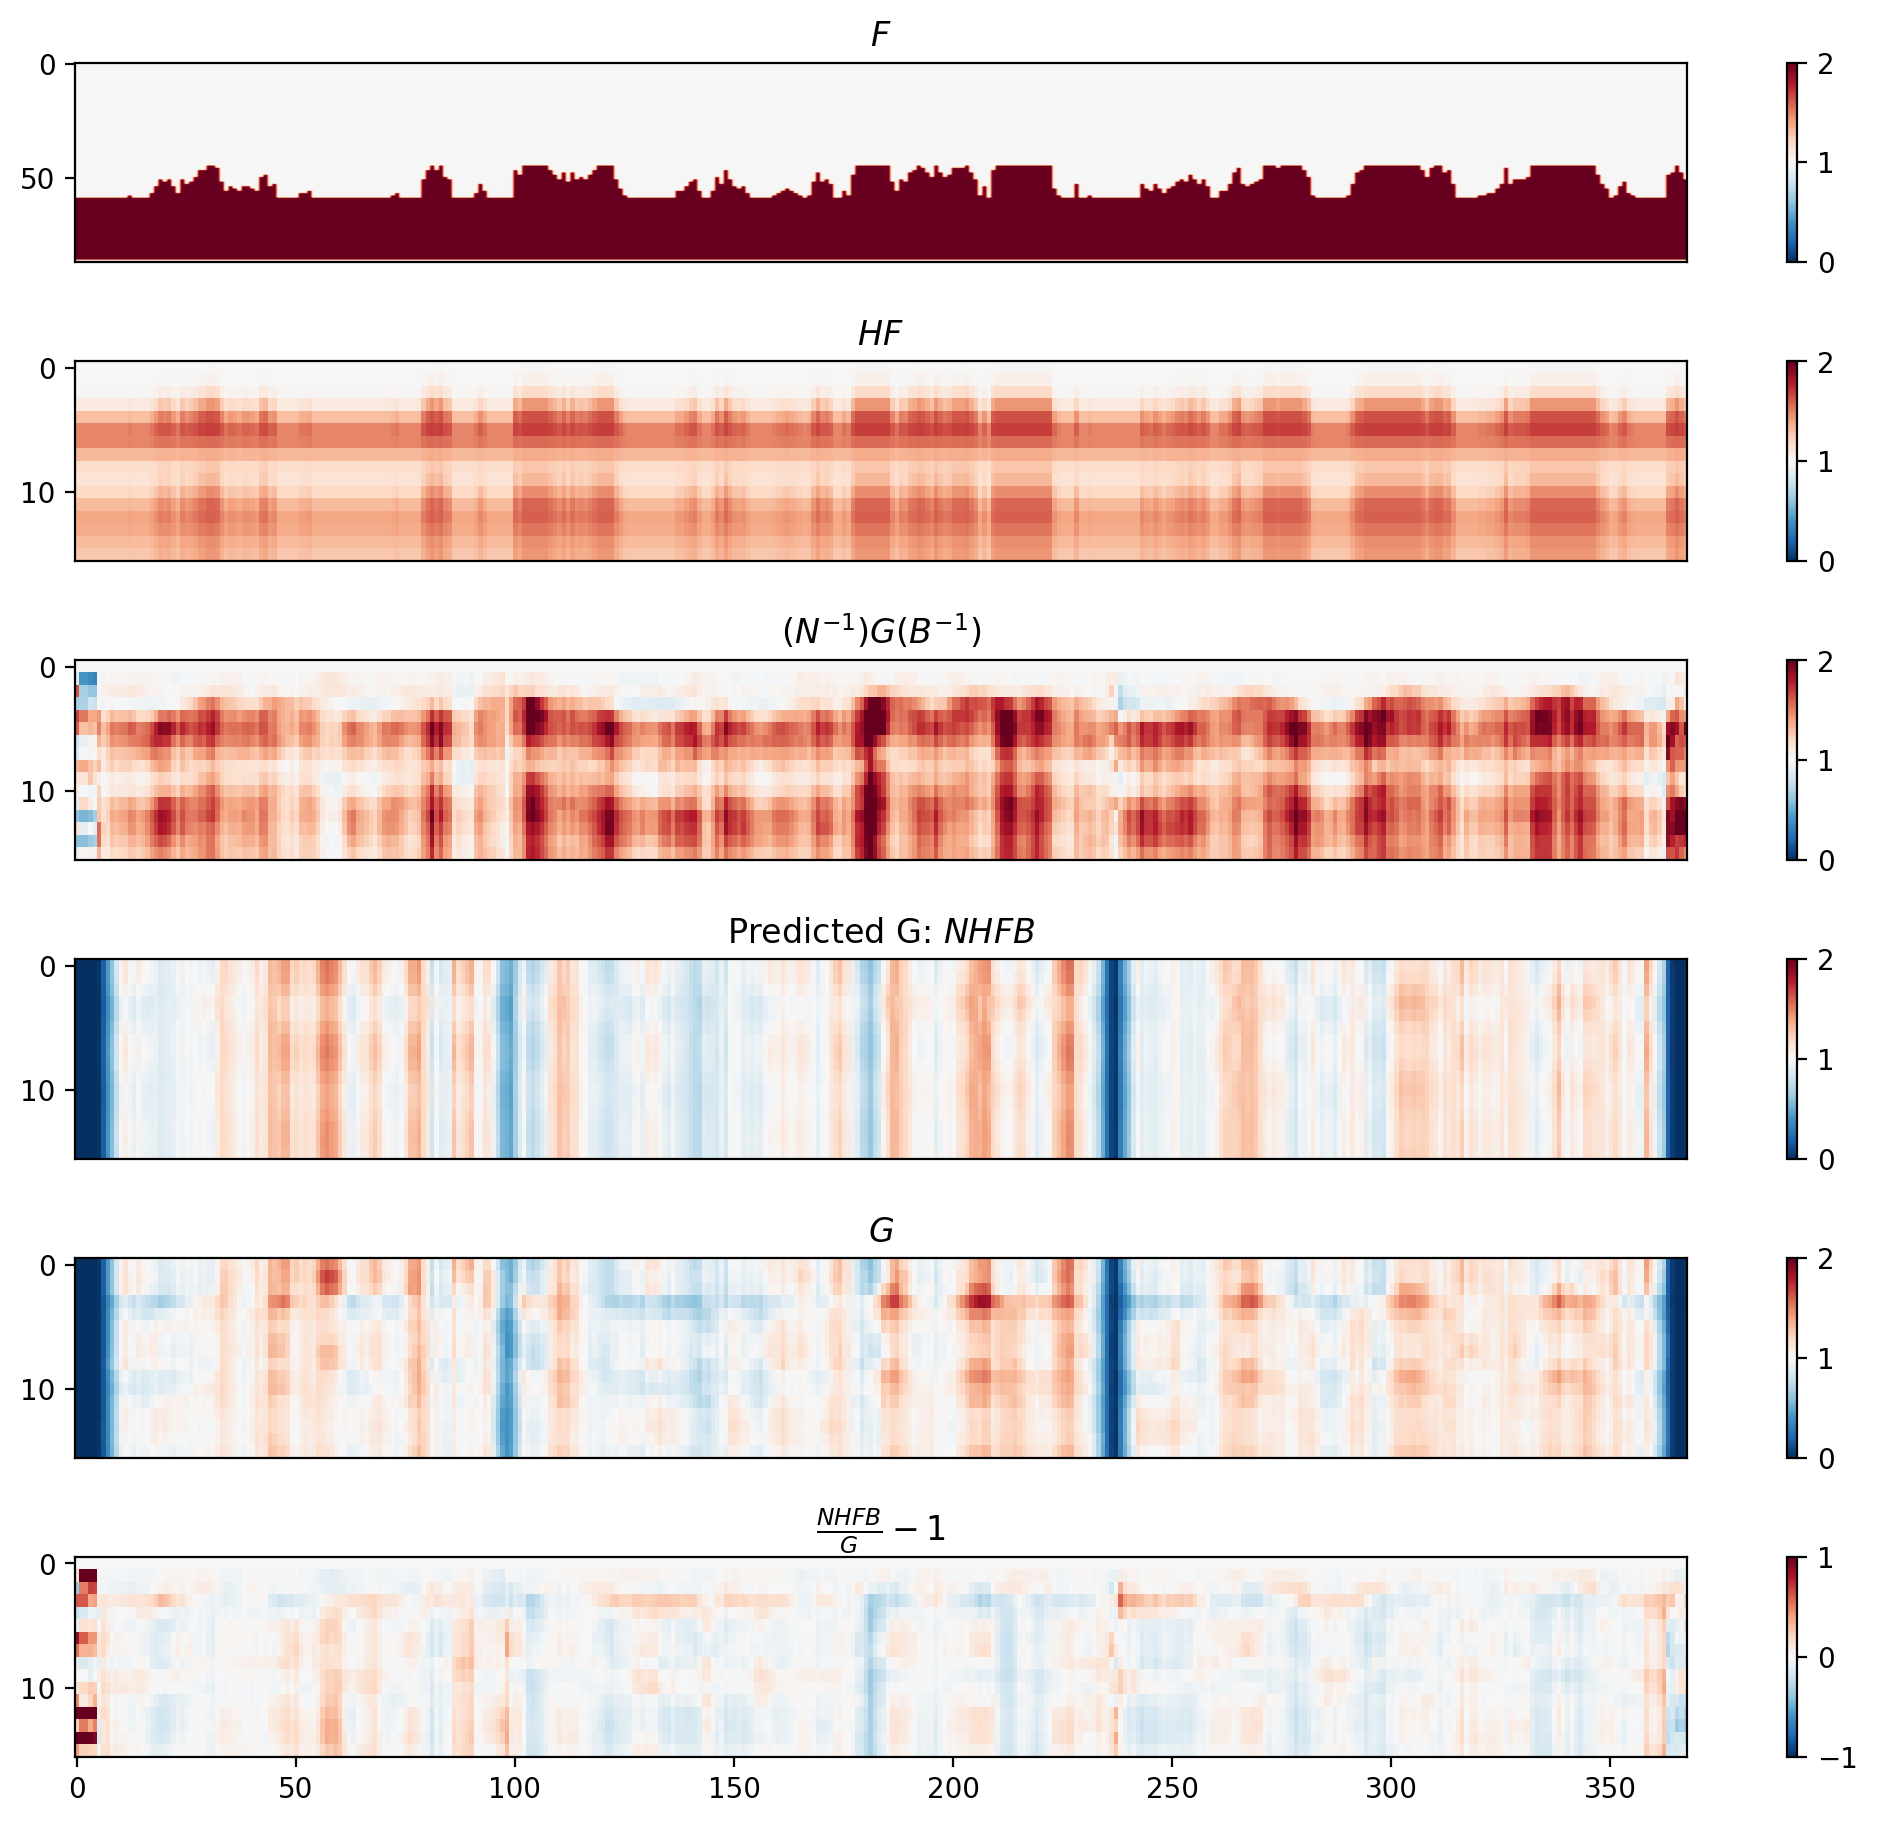

In [21]:
real_deconv1.plot_heatmaps()

In [94]:
from src.RealDataReplication import RealDataReplicationDeconvolution
from src.config import load_default_chrom_configs

config1, config2 = load_default_chrom_configs(longer_file=False)
real_deconv_combined = RealDataReplicationDeconvolution(configs=[config1, config2], 
    deconvolve_combined=True)


todo: Copy correction is not in place
Setting up combined deconvolution model
Initializing N using config H.
Initializing B using timepoint 0
Initializing N using config H.
Initializing B using timepoint 0


In [95]:
real_deconv_combined.deconvolve()

0/368 - 00:00:00.000
50/368 - 00:00:05.146
100/368 - 00:00:09.960
150/368 - 00:00:15.091
200/368 - 00:00:19.747
250/368 - 00:00:24.381
300/368 - 00:00:29.201
350/368 - 00:00:33.910


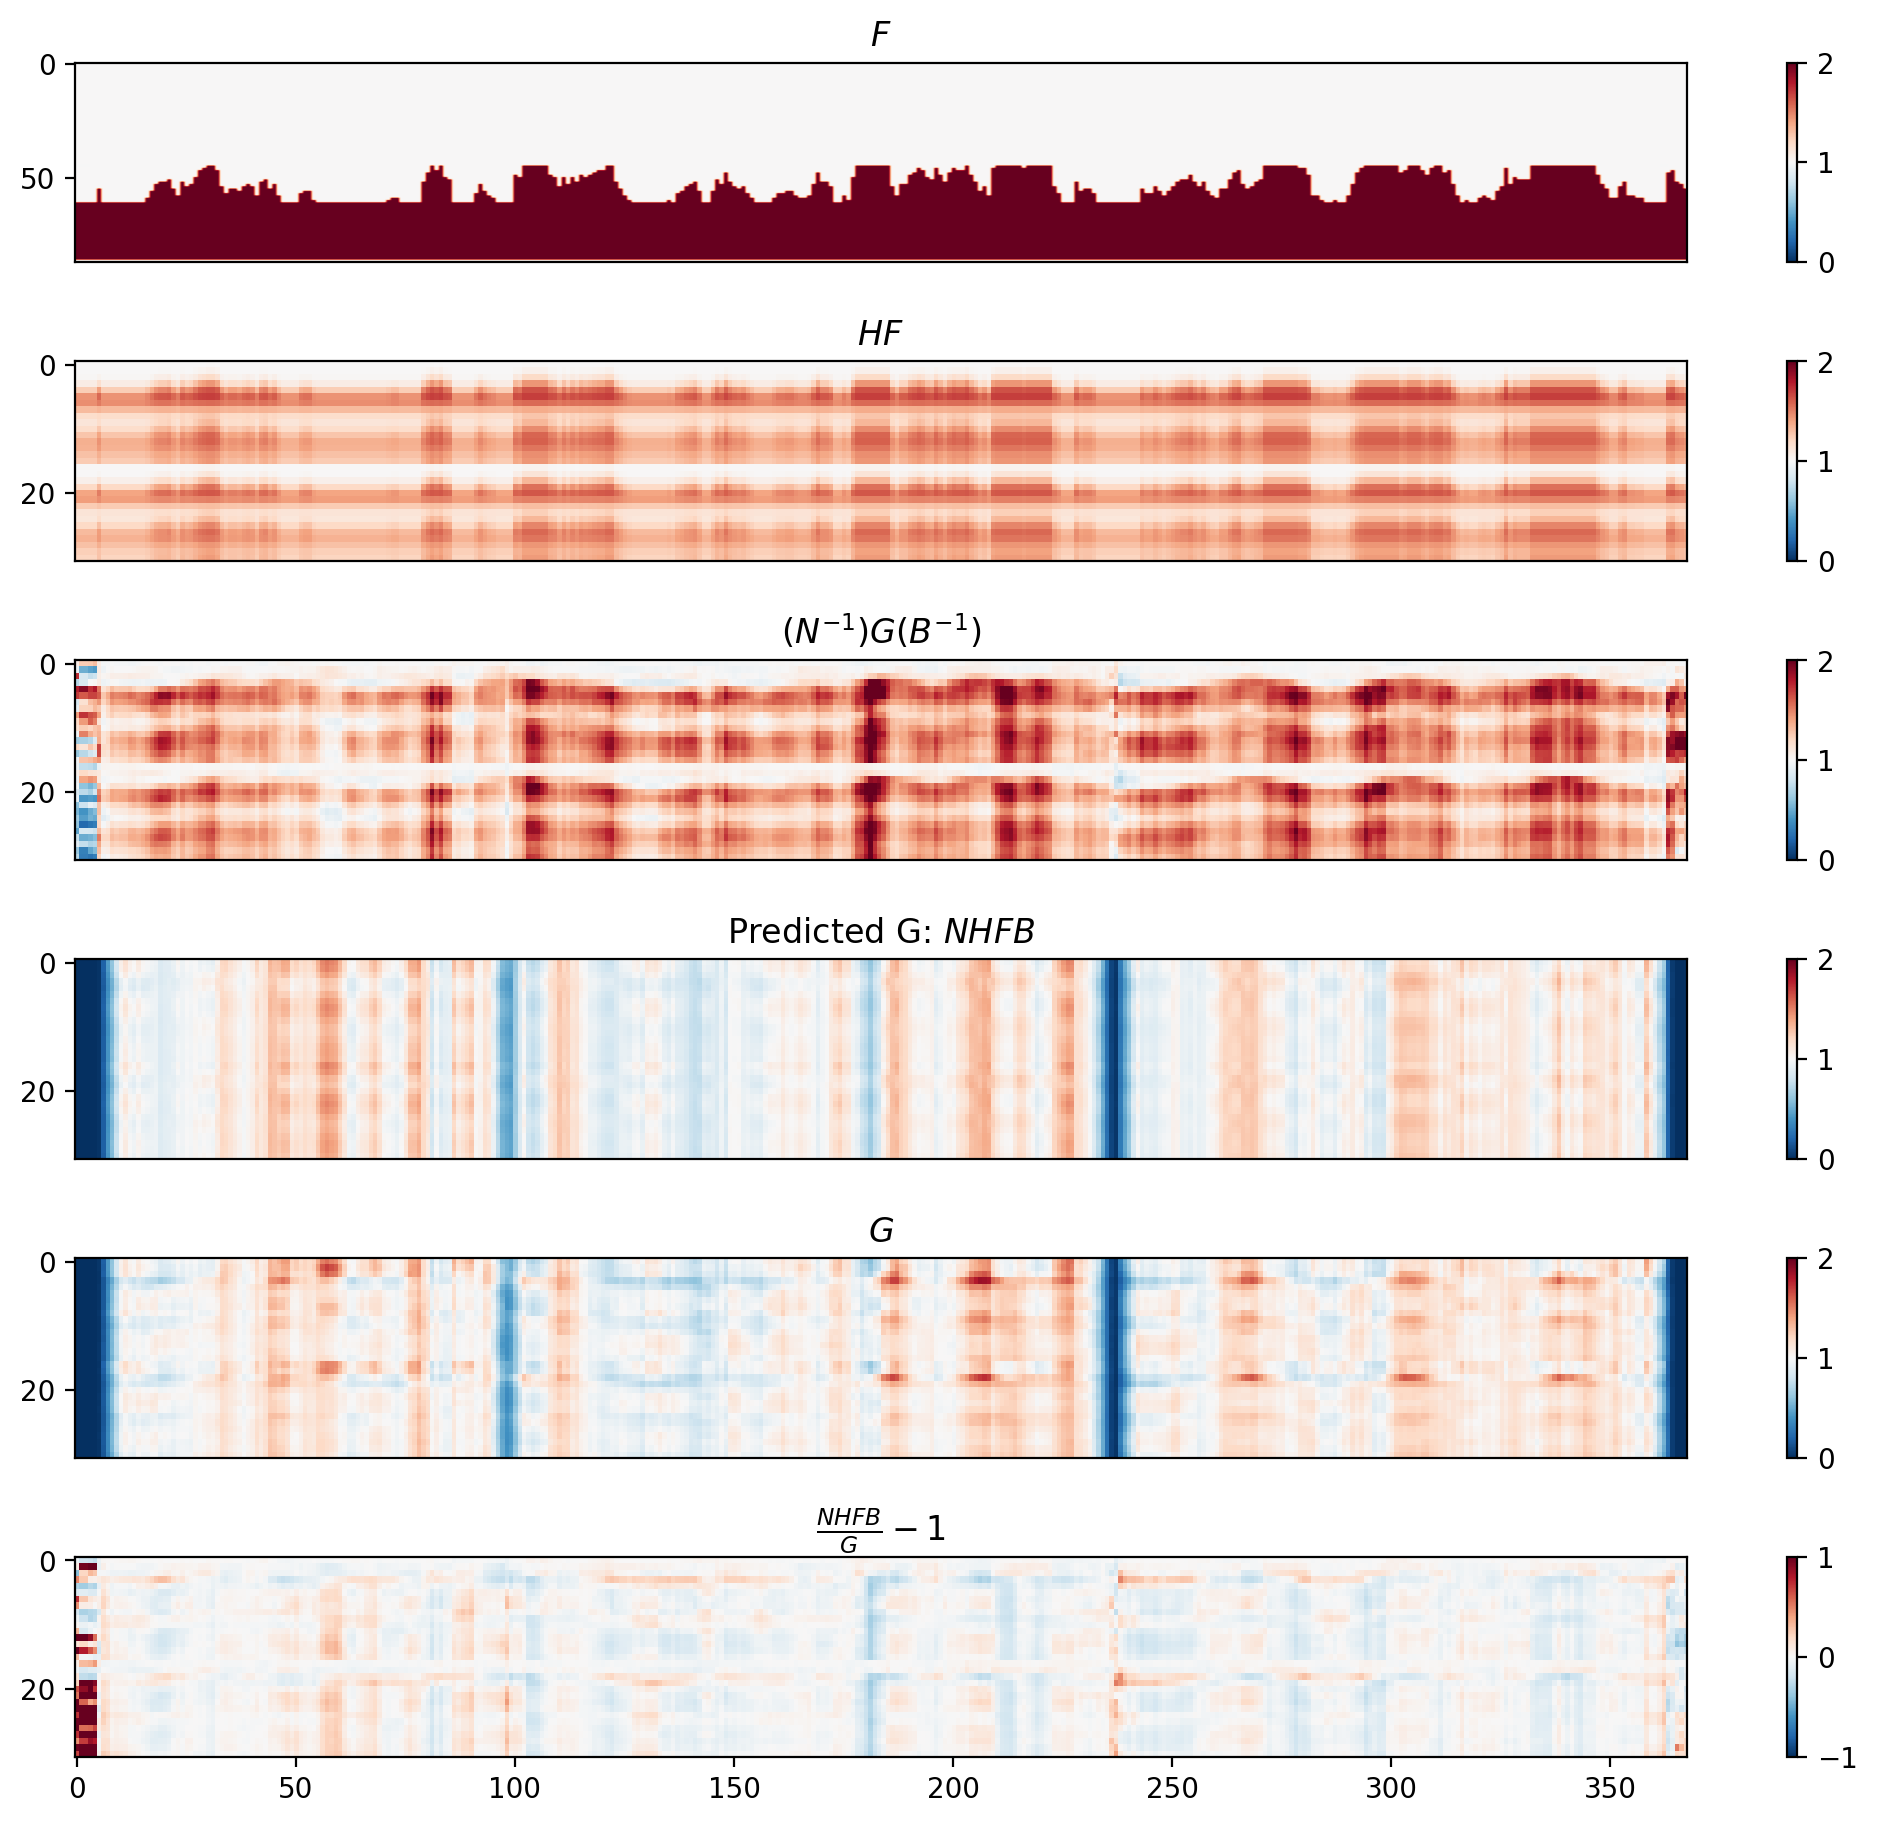

In [96]:
real_deconv_combined.plot_heatmaps()

Text(0.5, 1.0, 'Average DNA (clock time)')

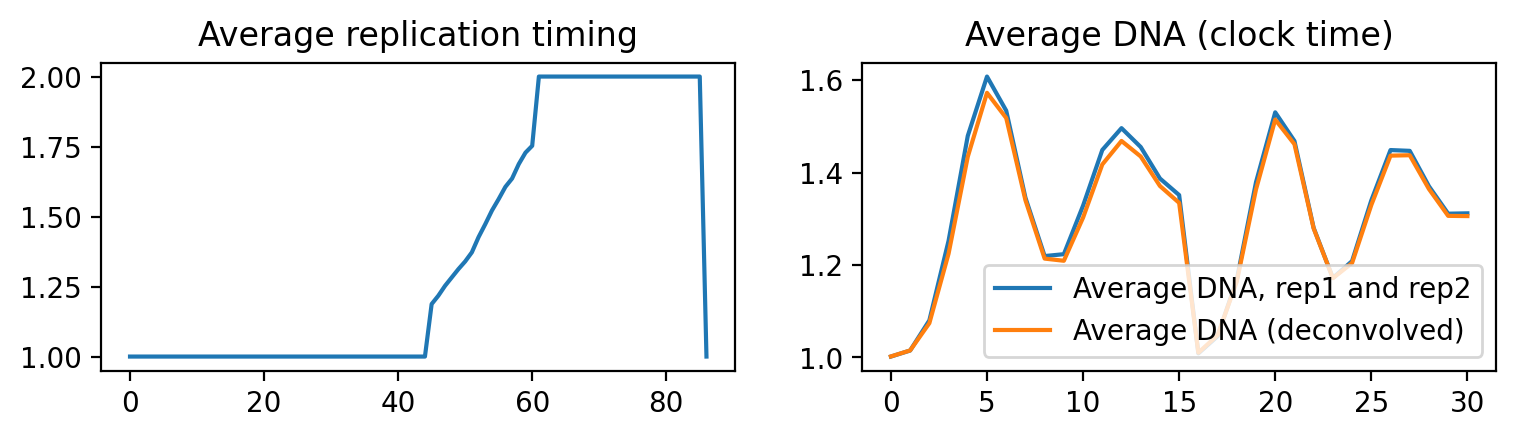

In [97]:
plt.figure(figsize=(9, 2))
plt.subplot(1, 2, 1)
plt.plot(real_deconv_combined.F.mean(axis=1), label="Mean F")
plt.title("Average replication timing")

plt.subplot(1, 2, 2)
plt.plot(real_deconv_combined.average_DNA, label="Average DNA, rep1 and rep2")
plt.plot(real_deconv_combined.H@real_deconv_combined.F.mean(axis=1), 
    label="Average DNA (deconvolved)")
plt.legend()
plt.title("Average DNA (clock time)")

In [112]:
real_deconv_combined.save_replication_deconvolution()

Creating directory: data/copy_correction/...Directory exists. Skipping.
Saved to: data/copy_correction//N_combined.npy
Saved to: data/copy_correction//B_chr10_combined.csv
Saved to: data/copy_correction//F_chr10_combined.csv


In [113]:
real_deconv_combined = RealDataReplicationDeconvolution(configs=[config1, config2], 
    replicate=1, deconvolve_combined=True, chr=16)

Setting up combined deconvolution model
Initializing N using config H.
Initializing B using timepoint 0
Initializing N using config H.
Initializing B using timepoint 0


In [114]:
real_deconv_combined.deconvolve()

0/470 - 00:00:00.000
50/470 - 00:00:04.775
100/470 - 00:00:09.615
150/470 - 00:00:14.213
200/470 - 00:00:19.095
250/470 - 00:00:23.997
300/470 - 00:00:28.422
350/470 - 00:00:33.213
400/470 - 00:00:37.892
450/470 - 00:00:43.015


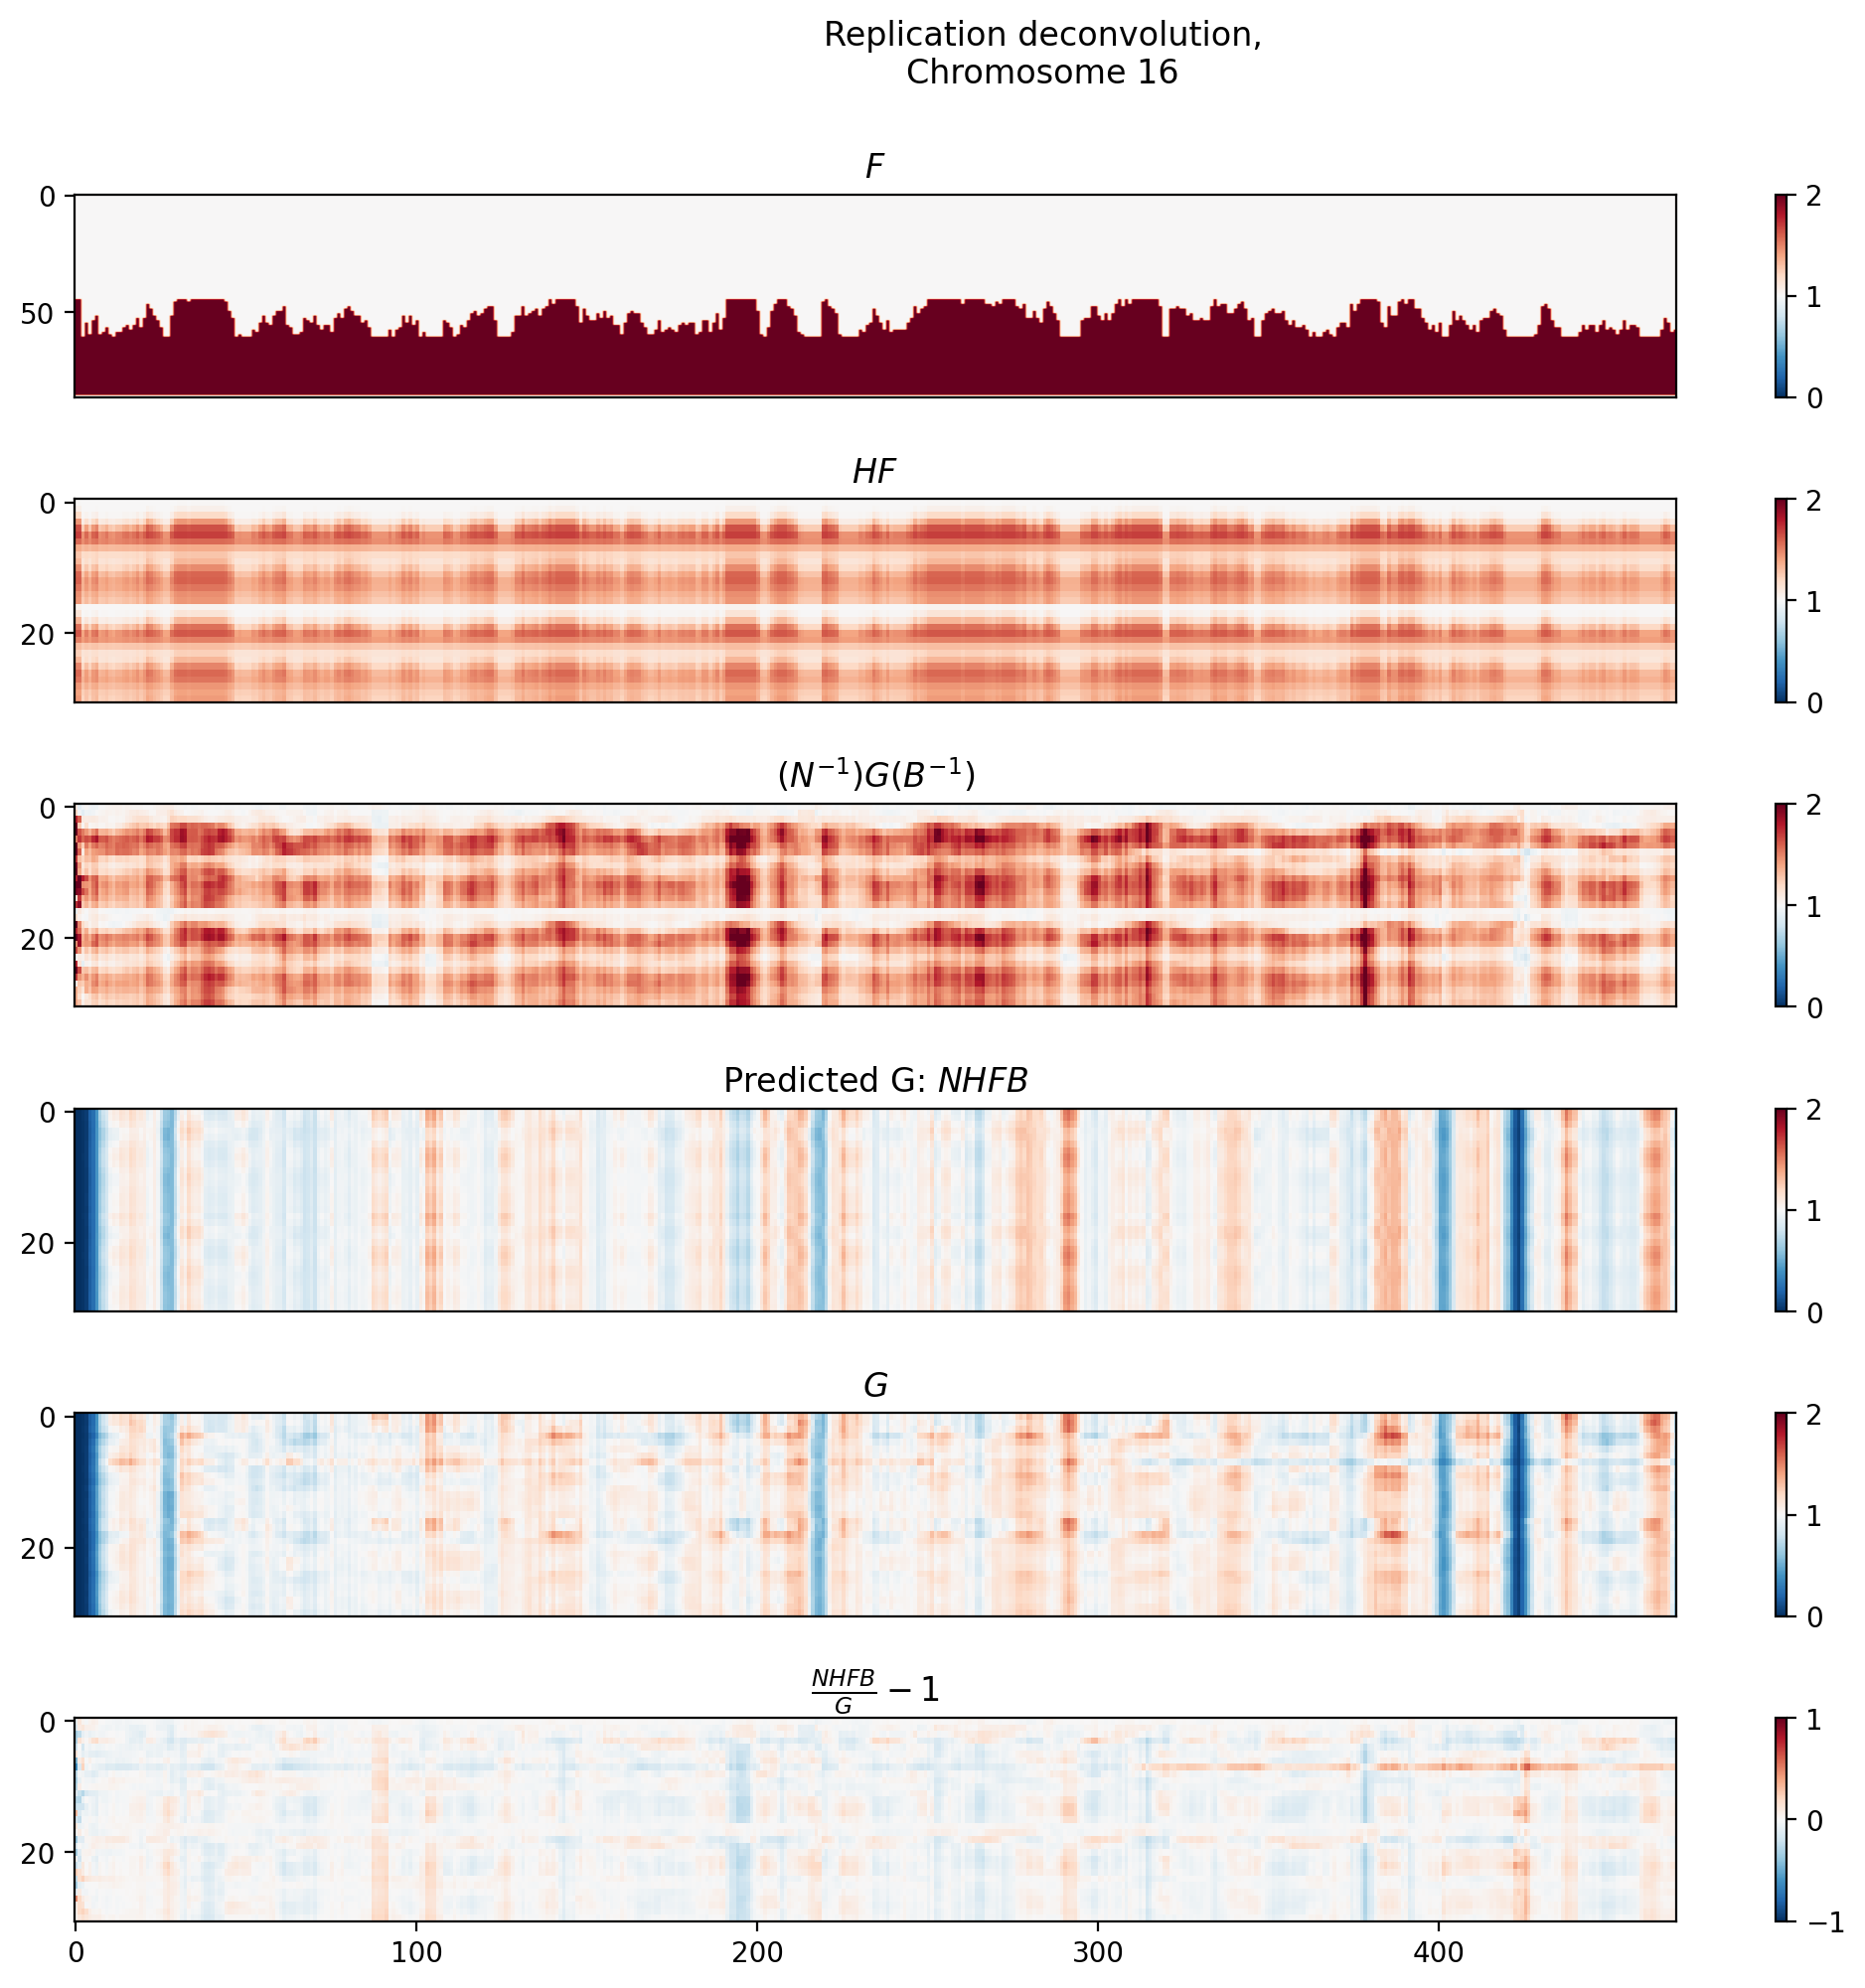

In [120]:
real_deconv_combined.plot_heatmaps()

In [115]:
real_deconv_combined.save_replication_deconvolution()

Creating directory: data/copy_correction/...Directory exists. Skipping.
Saved to: data/copy_correction//N_combined.npy
Saved to: data/copy_correction//B_chr16_combined.csv
Saved to: data/copy_correction//F_chr16_combined.csv


In [130]:
from src.timer import Timer

timer = Timer()
for chrom in range(1, 17):
    print("Chromosome", chrom)
    real_deconv_combined = RealDataReplicationDeconvolution(configs=[config1, config2], 
        deconvolve_combined=True, chr=chrom)
    real_deconv_combined.deconvolve()
    real_deconv_combined.save_replication_deconvolution()
    timer.print_time()


Chromosome 1
Setting up combined deconvolution model
Initializing N using config H.
Initializing B using timepoint 0
Initializing N using config H.
Initializing B using timepoint 0
0/111 - 00:00:00.000
50/111 - 00:00:05.388
100/111 - 00:00:12.307
Creating directory: data/copy_correction/...Directory exists. Skipping.
Saved to: data/copy_correction//N_combined.npy
Saved to: data/copy_correction//B_chr1_combined.csv
Saved to: data/copy_correction//F_chr1_combined.csv
00:00:19.383
Chromosome 2
Setting up combined deconvolution model
Initializing N using config H.
Initializing B using timepoint 0
Initializing N using config H.
Initializing B using timepoint 0
0/402 - 00:00:00.000
50/402 - 00:00:04.603
100/402 - 00:00:09.060
150/402 - 00:00:13.567
200/402 - 00:00:18.152
250/402 - 00:00:22.835
300/402 - 00:00:27.450
350/402 - 00:00:32.191
400/402 - 00:00:36.865
Creating directory: data/copy_correction/...Directory exists. Skipping.
Saved to: data/copy_correction//N_combined.npy
Saved to: dat

Chromosome 15
Setting up combined deconvolution model
Initializing N using config H.
Initializing B using timepoint 0
Initializing N using config H.
Initializing B using timepoint 0
0/541 - 00:00:00.000
50/541 - 00:00:04.674
100/541 - 00:00:09.437
150/541 - 00:00:13.951
200/541 - 00:00:18.737
250/541 - 00:00:24.115
300/541 - 00:00:28.975
350/541 - 00:00:33.917
400/541 - 00:00:38.706
450/541 - 00:00:43.500
500/541 - 00:00:48.165
Creating directory: data/copy_correction/...Directory exists. Skipping.
Saved to: data/copy_correction//N_combined.npy
Saved to: data/copy_correction//B_chr15_combined.csv
Saved to: data/copy_correction//F_chr15_combined.csv
00:14:51.380
Chromosome 16
Setting up combined deconvolution model
Initializing N using config H.
Initializing B using timepoint 0
Initializing N using config H.
Initializing B using timepoint 0
0/470 - 00:00:00.000
50/470 - 00:00:04.832
100/470 - 00:00:09.912
150/470 - 00:00:14.430
200/470 - 00:00:19.471
250/470 - 00:00:24.467
300/470 - 00: